# Cluster LOCO metrics

## Cluster LOCO Split: Cluster-LOCO feature importance with data splitting

Generate data from a GMM with $p=10, n_k=100, K=3$ with $5$ noise features.

In [1]:
import sys
sys.path.append('../')
from simulations import BaseSimulator

In [2]:
bs = BaseSimulator(3, 100, d_0=5, alpha=1.3, method='gaussian')
_, y = bs.generate_data()
X = bs.add_noise(noise_d=5)

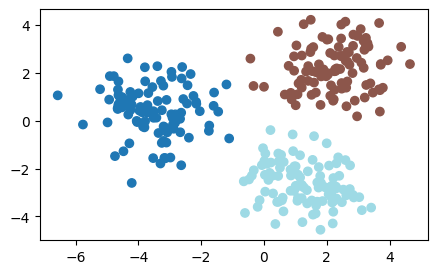

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(5,3))
plt.scatter(X_pca[:,0],X_pca[:,1], c=y, cmap='tab20')

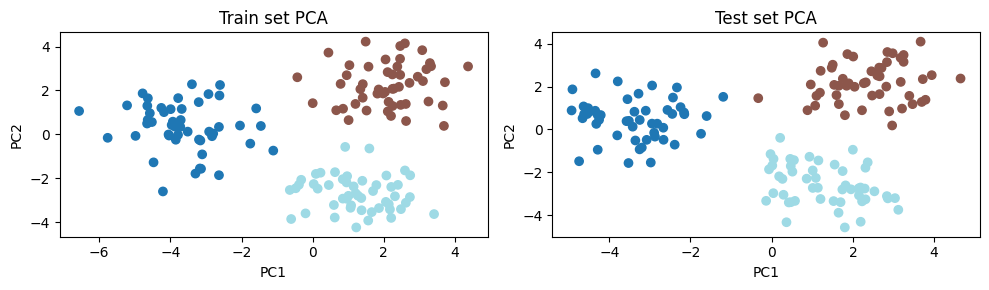

In [4]:
from clim import Cluster_LOCO_Split, hinge_error
from sklearn.model_selection import train_test_split

X_train, X_test, X_pca_train, X_pca_test, y_train, y_test = train_test_split(X, X_pca, y, test_size=0.5, random_state=42, stratify=y)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].scatter(X_pca_train[:, 0], X_pca_train[:, 1], c=y_train, cmap="tab20")
ax[0].set_title("Train set PCA")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[1].scatter(X_pca_test[:, 0], X_pca_test[:, 1], c=y_test, cmap="tab20")
ax[1].set_title("Test set PCA")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
mean_imp, se_imp = Cluster_LOCO_Split(X_train, X_test, model=model, error_metric=hinge_error, K=3, use_proba=True, seed=42)

Reset n_clusters to 3


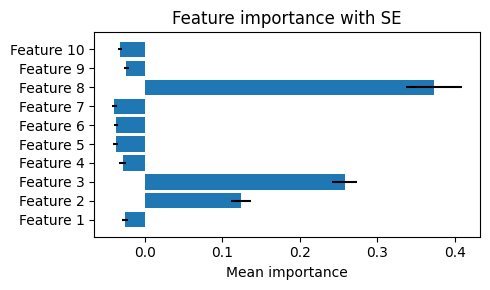

In [6]:
import numpy as np
plt.figure(figsize=(5,3))
plt.barh(np.arange(10), mean_imp, xerr=se_imp/np.sqrt(X_test.shape[0]))
plt.yticks(np.arange(10), [f"Feature {i+1}" for i in range(10)])
plt.xlabel("Mean importance")
plt.title("Feature importance with SE")
plt.tight_layout()
plt.show()

## Cluster LOCO-MP: Cluster-LOCO with MP for fast inference

Generate data with $p=100$ with $50$ noise features, $K=3, n_k=100$.

In [7]:
bs = BaseSimulator(3, 100, d_0=50, alpha=0.8, method='gaussian')
_, y = bs.generate_data()
X = bs.add_noise(noise_d=50)

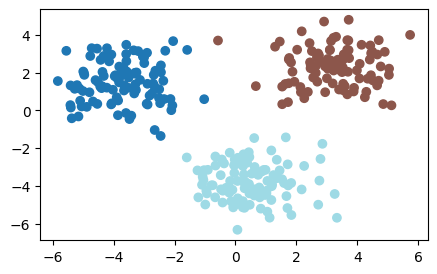

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(5,3))
plt.scatter(X_pca[:,0],X_pca[:,1], c=y, cmap='tab20')

In [9]:
from clim import ClusterLOCOMP
from sklearn.ensemble import RandomForestClassifier
model = KMeans(n_clusters=3)

In [11]:
print("---- Cluster LOCOMP ----")
par = {"n_jobs_features":5,
   "backend":"loky",
   "prefer":"processes",
   "verbose":True,
  }

g = ClusterLOCOMP(base_clusterer = model, base_classifier = RandomForestClassifier(), K=3, B=600)
g.fit(X, standardize=False, alpha_N = 0.2, alpha_M = 0.2, parallel=par)

---- Cluster LOCOMP ----
---------- Generate minipatches ------------
---------- Minipatch clustering ------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


---------- Minipatch reference ------------
---------- Minipatch training ------------


[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 352 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:    6.7s finished


In [12]:
out = g.score(error_metric=hinge_error, agg='mean', proba_error=True, parallel_features=False) # don't parallelize with features, overhead too expensive

100it [00:24,  4.13it/s]


<BarContainer object of 100 artists>

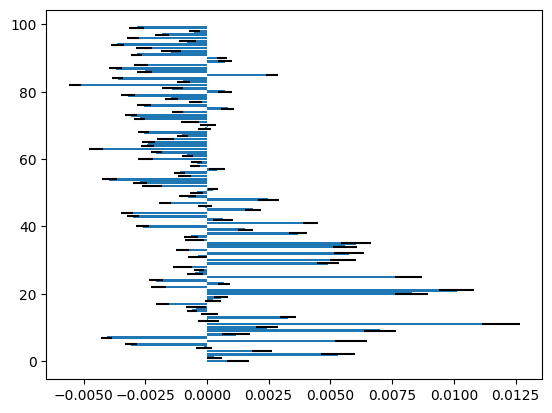

In [13]:
plt.barh(out['features'], out['delta'], xerr=out['delta_se'])

## Cluster LOCO-RAMPART: Cluster-LOCO with adaptive feature trimming

In [10]:
from clim import RAMPART, ClusterLOCO_RAMPART
from clim.minipatches.rampart import transform_scores_to_ranking

In [11]:
print("---- Cluster LOCO RAMPART ----")
gen_fn = ClusterLOCO_RAMPART(
    base_clusterer=model,
    K=3,
    error_metric=hinge_error,
    parallel_MP=True,
    parallel={"n_jobs_features": 3, "backend": "loky", "prefer": "processes", "verbose": 0},
    standardize=False,
    alpha_N = 0.2,
    alpha_M = 0.2
)
out = RAMPART(
    X,
    generalizability_fn=gen_fn,
    B=200,
    ranking_fn=transform_scores_to_ranking,
    top_k=50,
    gen_kwargs={},
)


---- Cluster LOCO RAMPART ----
---------- Generate minipatches ------------
---------- Minipatch clustering ------------
---------- Minipatch reference ------------
---------- Minipatch training ------------


100it [00:00, 819.66it/s]


[RAMPART] round 1/1: |C_t|=100 → |C_2|=50 (best feat=46, score=0.0195)
---------- Generate minipatches ------------
---------- Minipatch clustering ------------
---------- Minipatch reference ------------
---------- Minipatch training ------------


50it [00:00, 770.58it/s]


<BarContainer object of 100 artists>

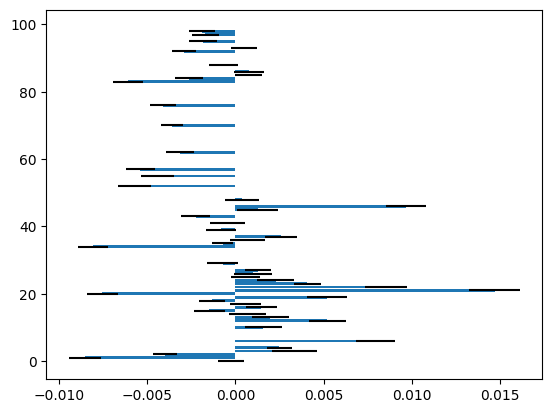

In [13]:
rampart_scores, rampart_std = np.zeros((100,)), np.zeros((100,))
rampart_scores[out['selected_indices']]= out['selected_scores']
rampart_std[out['selected_indices']]= out['selected_std']
plt.barh(np.arange(100),rampart_scores, xerr=rampart_std)